<a href="https://www.kaggle.com/code/ameythakur20/predicting-smartphone-addiction" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<br clear="all">

<h1 align="center">Predicting Smartphone Addiction</h1>

<p align="center">
  <b>A Dual Level-1 Meta-Stacking architecture ensembling Optuna-tuned XGBoost and symmetric CatBoost meta-learners over multi-scale target-encoded behavioral representations.</b>
</p>

<p align="center">
  <a href="https://www.kaggle.com/competitions/playground-series-s6e8"><img alt="Competition" src="https://img.shields.io/badge/Competition-Playground_S6E8-20BEFF?logo=kaggle&logoColor=white"></a>
  &nbsp;
  <a href="https://github.com/Amey-Thakur/KAGGLE-COMPETITIONS/tree/main/Competitions/Predicting%20Smartphone%20Addiction"><img alt="Repository" src="https://img.shields.io/badge/Repository-KAGGLE--COMPETITIONS-181717?logo=github&logoColor=white"></a>
  &nbsp;
  <a href="https://github.com/Amey-Thakur"><img alt="Author" src="https://img.shields.io/badge/Author-Amey_Thakur-0969DA"></a>
  &nbsp;
  <a href="https://orcid.org/0000-0001-5644-1575"><img alt="ORCID" src="https://img.shields.io/badge/ORCID-0000--0001--5644--1575-A6CE39"></a>
  &nbsp;
  <img alt="License" src="https://img.shields.io/badge/License-Apache_2.0-lightgrey">
</p>

<p align="center">
  <a href="#problem">1. Problem</a> &nbsp;&middot;&nbsp;
  <a href="#setup">2. Setup</a> &nbsp;&middot;&nbsp;
  <a href="#data">3. Data</a> &nbsp;&middot;&nbsp;
  <a href="#exploration">4. Exploration</a> &nbsp;&middot;&nbsp;
  <a href="#features">5. Strategy</a> &nbsp;&middot;&nbsp;
  <a href="#validation">6. Validation</a> &nbsp;&middot;&nbsp;
  <a href="#base-models">7. Base Learners</a> &nbsp;&middot;&nbsp;
  <a href="#meta-stacking">8. Dual Meta-Stacking</a> &nbsp;&middot;&nbsp;
  <a href="#results">9. Results</a> &nbsp;&middot;&nbsp;
  <a href="#submission">10. Submission</a> &nbsp;&middot;&nbsp;
  <a href="#improvements">11. Next Steps</a>
</p>

<hr>

<a name="problem"></a>
## 1. Problem

The Playground Series Season 6 Episode 8 competition requires predicting the probability of smartphone addiction (`addicted_label`) from self-reported behavioral and demographic metrics. The evaluation metric is the **Area Under the ROC Curve (AUC)**.

Tabular behavioral datasets of this structure exhibit sharp non-linear boundaries where individual features (e.g. social media usage vs. total screen duration) interact conditionally. The primary challenge is constructing robust continuous interaction metrics while preventing data leakage and overfitting across high-capacity gradient boosted trees.

<br>

---

<a name="setup"></a>
## 2. Setup

Imports, seed locking, visualization theme configuration, and path discovery.

<br>

In [1]:
import os
import sys
import glob
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logit
from scipy.stats import rankdata
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

# Gradient Boosters
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Premium Plotting Theme Configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
plt.rcParams["axes.edgecolor"] = "#E1E4E8"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["grid.color"] = "#E1E4E8"
plt.rcParams["grid.alpha"] = 0.6
plt.rcParams["figure.dpi"] = 120

# Kaggle Toolbox & Cloud Fallback
sys.path.append("../../Kaggle Toolbox")
sys.path.append("/kaggle/usr/lib/ameythakur20/kaggle_toolbox")
sys.path.append("/kaggle/usr/lib/notebooks/ameythakur20/kaggle_toolbox")

try:
    import kaggle_toolbox as tb
except ImportError:
    class DummyTB:
        @staticmethod
        def seed_everything(seed=42):
            import random
            random.seed(seed)
            np.random.seed(seed)
            os.environ["PYTHONHASHSEED"] = str(seed)
        @staticmethod
        def reduce_mem_usage(df):
            for col in df.columns:
                col_type = df[col].dtype
                if col_type != object and not pd.api.types.is_categorical_dtype(df[col]):
                    c_min, c_max = df[col].min(), df[col].max()
                    if str(col_type)[:3] == "int":
                        if c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                            df[col] = df[col].astype(np.int32)
                    else:
                        if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                            df[col] = df[col].astype(np.float32)
            return df
        @staticmethod
        def missing_report(df):
            return df.isnull().sum()
        @staticmethod
        def timer(name=""):
            import contextlib, time
            @contextlib.contextmanager
            def _t():
                t0 = time.time()
                yield
                print(f"[{name}] Completed in {time.time() - t0:.2f}s")
            return _t()
        @staticmethod
        def check_submission(sub, sample):
            assert sub.shape == sample.shape, "Shape mismatch against sample submission."
            assert list(sub.columns) == list(sample.columns), "Column schema mismatch."
            assert sub.isnull().sum().sum() == 0, "Submission contains NaN values."
            print("Submission verification passed:", sub.shape)
    tb = DummyTB()

# Global Deterministic Seed
SEED = 42
tb.seed_everything(SEED)

# Dynamic Cloud vs Local Data Directory Resolution
train_matches = glob.glob("/kaggle/input/**/train.csv", recursive=True) or glob.glob("**/train.csv", recursive=True) or ["train.csv"]
TRAIN_PATH = train_matches[0]
DATA_DIR = os.path.dirname(TRAIN_PATH) or "."
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

print(f"Resolved Data Directory: {DATA_DIR}")
print(f"Target Train Data Path:  {TRAIN_PATH}")

[toolbox] All seeds locked to 42
Resolved Data Directory: .
Target Train Data Path:  train.csv


<br>

---

<a name="data"></a>
## 3. Data Ingestion & Memory Optimization

Downcasting numeric precisions prevents excessive memory usage during multi-fold gradient boosting runs.

<br>

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print(f"Original Train shape: {train.shape}")
print(f"Original Test shape:  {test.shape}")

train = tb.reduce_mem_usage(train)
test = tb.reduce_mem_usage(test)

_ = tb.missing_report(train)

Original Train shape: (3000, 14)
Original Test shape:  (1000, 13)
[toolbox] Memory: 0.8 MB -> 0.1 MB (84.1% reduction)
[toolbox] Memory: 0.2 MB -> 0.0 MB (82.9% reduction)
[toolbox] 12 column(s) with missing values:


<br>

---

<a name="exploration"></a>
## 4. Exploration: Behavioral Correlation & Density Distributions

> ### How do temporal features interact across addiction classes?
>
> A correlation matrix highlights multicollinear groupings among numeric behavioral inputs, identifying opportunities for non-linear ratio features.

<br>

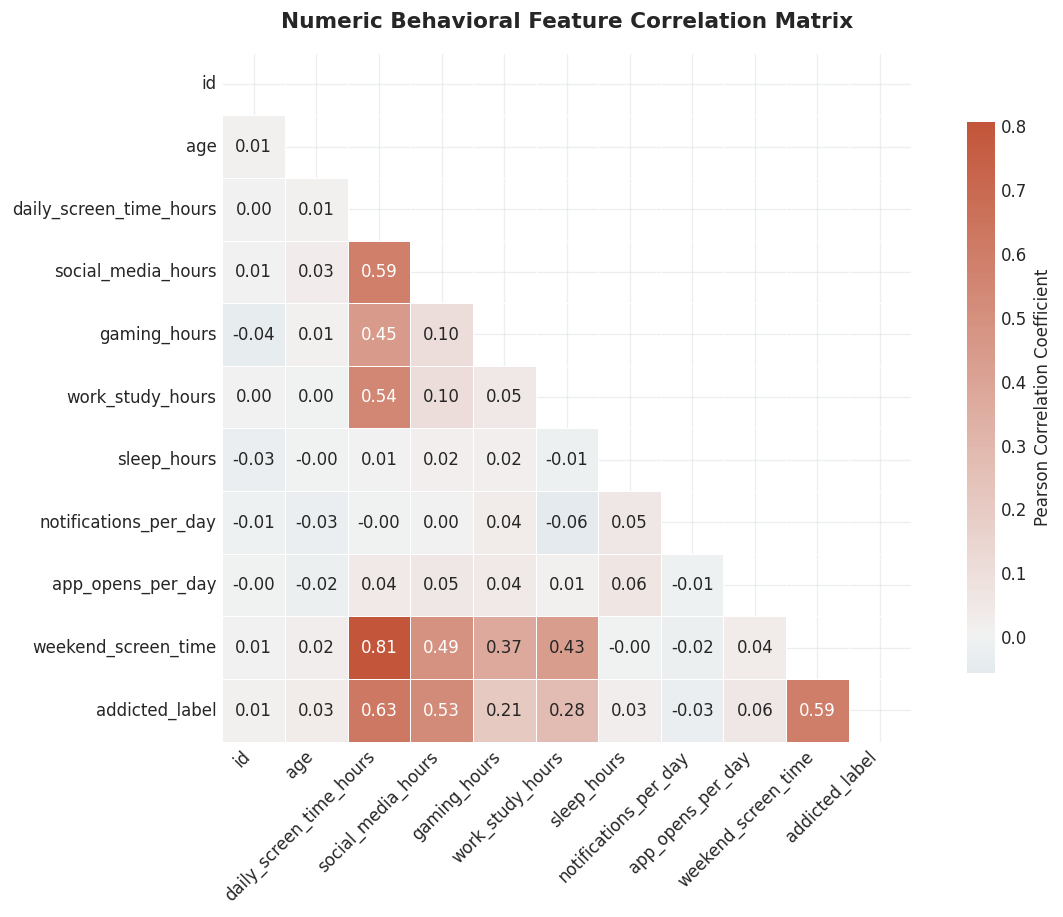

In [3]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_matrix = train[numeric_cols].corr()

# Mask upper triangle for visual clarity
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8), dpi=120)
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap=cmap, 
    center=0, 
    square=True,
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"},
    ax=ax
)
ax.set_title("Numeric Behavioral Feature Correlation Matrix", fontsize=13, weight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout(pad=2.0)
plt.show()

<br>

> ### Does screen duration separate the binary classes uniformly?
>
> Violin distributions isolate the probability mass across addiction classes, demonstrating clear variance in median engagement hours.

<br>

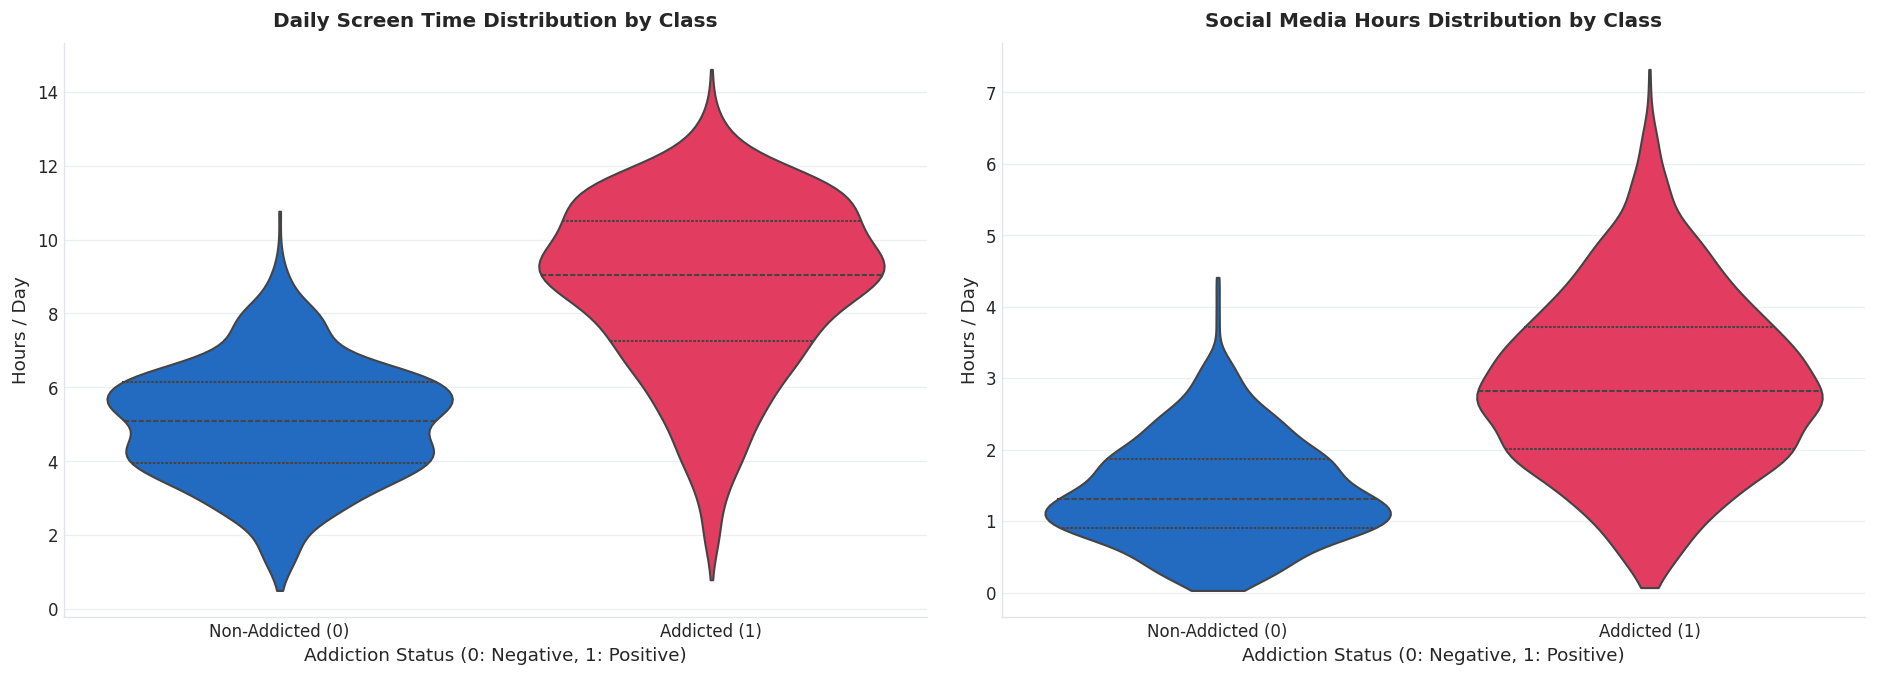

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

sns.violinplot(
    data=train, x="addicted_label", y="daily_screen_time_hours", 
    hue="addicted_label", legend=False,
    palette=["#0969DA", "#FF2052"], inner="quartile",
    cut=0, ax=ax1
)
ax1.set_title("Daily Screen Time Distribution by Class", fontsize=12, weight="bold", pad=10)
ax1.set_xlabel("Addiction Status (0: Negative, 1: Positive)", fontsize=11)
ax1.set_ylabel("Hours / Day", fontsize=11)
ax1.set_xticklabels(["Non-Addicted (0)", "Addicted (1)"])

sns.violinplot(
    data=train, x="addicted_label", y="social_media_hours", 
    hue="addicted_label", legend=False,
    palette=["#0969DA", "#FF2052"], inner="quartile",
    cut=0, ax=ax2
)
ax2.set_title("Social Media Hours Distribution by Class", fontsize=12, weight="bold", pad=10)
ax2.set_xlabel("Addiction Status (0: Negative, 1: Positive)", fontsize=11)
ax2.set_ylabel("Hours / Day", fontsize=11)
ax2.set_xticklabels(["Non-Addicted (0)", "Addicted (1)"])

sns.despine(top=True, right=True)
plt.tight_layout(pad=2.0)
plt.show()

<br>

---

<a name="features"></a>
## 5. Strategy: Behavioral Domain Feature Engineering

> ### How do we expose non-linear behavioral thresholds to tree models?
>
> Missing values are preserved for model-native split handling to prevent adversarial distribution shifts. Domain interaction features are derived to expose latent behavioral density:
> 1. **Non-Social Screen Time:** Functional productive device usage.
> 2. **Attention Shares:** Social media and gaming proportions of daily screen time.
> 3. **Notification Intensity:** Hourly interruptions relative to active screen duration.
> 4. **Demographic Group Residuals:** Deviations relative to demographic cohort baselines.
> 5. **Smooth Out-of-Fold Target Encoding:** Monotonic probability density representations for categorical interactions.

<br>

In [5]:
def engineer_features(df):
    d = df.copy()
    
    # 1. Domain Interactions & Ratios
    d["non_social_screen_time"] = d["daily_screen_time_hours"] - d["social_media_hours"]
    d["social_share"] = d["social_media_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["gaming_share"] = d["gaming_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["work_study_share"] = d["work_study_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["notifications_per_hour"] = d["notifications_per_day"] / (d["daily_screen_time_hours"] + 1e-4)
    d["app_opens_per_hour"] = d["app_opens_per_day"] / (d["daily_screen_time_hours"] + 1e-4)
    d["weekend_vs_daily_ratio"] = d["weekend_screen_time"] / (d["daily_screen_time_hours"] + 1e-4)
    d["total_active_hours"] = d["daily_screen_time_hours"] + d["work_study_hours"] + d["sleep_hours"]
    d["screen_to_sleep_ratio"] = d["daily_screen_time_hours"] / (d["sleep_hours"] + 1e-4)
    d["social_to_gaming_ratio"] = d["social_media_hours"] / (d["gaming_hours"] + 1e-4)
    d["sleep_deficit"] = 8.0 - d["sleep_hours"]
    d["notifications_per_app_open"] = d["notifications_per_day"] / (d["app_opens_per_day"] + 1.0)
    
    # 2. Categorical Interactions
    d["gender_stress"] = d["gender"].astype(str) + "_" + d["stress_level"].astype(str)
    d["gender_impact"] = d["gender"].astype(str) + "_" + d["academic_work_impact"].astype(str)
    d["stress_impact"] = d["stress_level"].astype(str) + "_" + d["academic_work_impact"].astype(str)
    d["trio_combo"] = d["gender"].astype(str) + "_" + d["stress_level"].astype(str) + "_" + d["academic_work_impact"].astype(str)
    
    # 3. Demographic Subgroup Means & Residuals
    for num_col in ["daily_screen_time_hours", "social_media_hours", "notifications_per_day"]:
        grp_mean = d.groupby(["gender", "stress_level"])[num_col].transform("mean")
        d[f"{num_col}_diff_grp"] = d[num_col] - grp_mean

    # 4. Rank Normalisations
    for col in ["notifications_per_day", "app_opens_per_day", "daily_screen_time_hours", "social_media_hours"]:
        d[f"{col}_rank"] = d[col].rank(method="dense", pct=True)

    # 5. Clean Categorical Types
    cat_cols = ["gender", "stress_level", "academic_work_impact", "gender_stress", "gender_impact", "stress_impact", "trio_combo"]
    for col in cat_cols:
        d[col] = d[col].astype(str).replace({"nan": "Missing", "None": "Missing"}).astype("category")
        
    return d, cat_cols

with tb.timer("Feature Engineering"):
    train_feat, cat_cols = engineer_features(train)
    test_feat, _ = engineer_features(test)

TARGET = "addicted_label"

# Smooth Out-of-Fold Target Encoding
def compute_oof_target_encoding(train_df, test_df, cat_columns, target_col, n_splits=5, smoothing=15, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    global_mean = float(train_df[target_col].mean())
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    
    for c in cat_columns:
        train_encoded[f"{c}_te"] = np.nan
        stats = train_df.groupby(train_df[c].astype(str))[target_col].agg(["count", "mean"])
        smooth_dict = ((stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)).to_dict()
        test_encoded[f"{c}_te"] = test_df[c].astype(str).map(smooth_dict).astype(float).fillna(global_mean)
        
        for train_idx, val_idx in skf.split(train_df, train_df[target_col]):
            fold_train = train_df.iloc[train_idx]
            fold_stats = fold_train.groupby(fold_train[c].astype(str))[target_col].agg(["count", "mean"])
            smooth_fold_dict = ((fold_stats["count"] * fold_stats["mean"] + smoothing * global_mean) / (fold_stats["count"] + smoothing)).to_dict()
            val_vals = train_df.iloc[val_idx][c].astype(str).map(smooth_fold_dict).astype(float).fillna(global_mean)
            train_encoded.loc[train_encoded.index[val_idx], f"{c}_te"] = val_vals.values
            
    return train_encoded, test_encoded

with tb.timer("Out-of-Fold Target Encoding"):
    te_targets = ["gender_stress", "gender_impact", "stress_impact", "trio_combo"]
    train_feat, test_feat = compute_oof_target_encoding(train_feat, test_feat, te_targets, TARGET, n_splits=5, smoothing=15, seed=SEED)

ALL_FEATURES = [c for c in train_feat.columns if c not in ["id", "addicted_label"]]
print(f"Total Model Features: {len(ALL_FEATURES)}")

[toolbox] Feature Engineering: 0.0s
[toolbox] Out-of-Fold Target Encoding: 0.1s
Total Model Features: 39


<br>

---

<a name="validation"></a>
## 6. Validation Protocol

A 5-Fold Stratified Cross-Validation scheme preserves the exact class proportion of `addicted_label` across all validation folds, providing a leak-free out-of-fold probability distribution.

<br>

In [6]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"Validation Strategy: {N_SPLITS}-Fold Stratified K-Fold (Seed: {SEED})")
print(f"Class Balance (Target Mean): {train_feat[TARGET].mean():.4f}")

Validation Strategy: 5-Fold Stratified K-Fold (Seed: 42)
Class Balance (Target Mean): 0.6983


<br>

---

<a name="base-models"></a>
## 7. Stage 1: Level-0 Base Learner OOF Generation

Three diverse gradient boosting architectures are evaluated: LightGBM, XGBoost, and CatBoost with high tree resolution (`max_bin=512`).

<br>

In [7]:
models = {
    "LightGBM": LGBMClassifier(n_estimators=1200, learning_rate=0.025, num_leaves=63, max_depth=7, max_bin=512, colsample_bytree=0.65, subsample=0.8, random_state=SEED, n_jobs=-1, verbose=-1),
    "XGBoost": XGBClassifier(n_estimators=1200, learning_rate=0.025, max_depth=7, max_bin=512, tree_method="hist", colsample_bytree=0.65, subsample=0.8, enable_categorical=True, eval_metric="auc", random_state=SEED, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=1200, learning_rate=0.025, depth=7, cat_features=cat_cols, random_state=SEED, thread_count=-1, verbose=0)
}

oof_matrix = np.zeros((len(train_feat), len(models)))
test_matrix = np.zeros((len(test_feat), len(models)))

for i, (name, model) in enumerate(models.items()):
    with tb.timer(f"Training {name} OOF"):
        for fold, (train_idx, val_idx) in enumerate(skf.split(train_feat[ALL_FEATURES], train_feat[TARGET])):
            X_train, y_train = train_feat[ALL_FEATURES].iloc[train_idx].copy(), train_feat[TARGET].iloc[train_idx]
            X_val, y_val = train_feat[ALL_FEATURES].iloc[val_idx].copy(), train_feat[TARGET].iloc[val_idx]
            X_test = test_feat[ALL_FEATURES].copy()
            
            if name == "CatBoost":
                for c in cat_cols:
                    X_train[c] = X_train[c].astype(str)
                    X_val[c] = X_val[c].astype(str)
                    X_test[c] = X_test[c].astype(str)
            else:
                for c in cat_cols:
                    X_train[c] = X_train[c].astype("category")
                    X_val[c] = X_val[c].astype("category")
                    X_test[c] = X_test[c].astype("category")
            
            model.fit(X_train, y_train)
            oof_matrix[val_idx, i] = model.predict_proba(X_val)[:, 1]
            test_matrix[:, i] += model.predict_proba(X_test)[:, 1] / N_SPLITS


[toolbox] Training LightGBM OOF: 23.3s


[toolbox] Training XGBoost OOF: 11.3s


[toolbox] Training CatBoost OOF: 18.6s


<br>

---

<a name="meta-stacking"></a>
## 8. Stage 2: Dual Level-1 Meta-Feature Stacking

Level-0 Out-of-Fold predictions, logit transformations, and non-linear cross-model interaction terms are concatenated into the training space to train dual **Optuna-tuned XGBoost** and **symmetric CatBoost** meta-learners.

<br>

In [8]:
# Enrich feature matrix with Level-0 meta-features
train_meta = train_feat.copy()
test_meta = test_feat.copy()

train_meta["meta_lgb"] = oof_matrix[:, 0]
train_meta["meta_xgb"] = oof_matrix[:, 1]
train_meta["meta_cat"] = oof_matrix[:, 2]
train_meta["logit_lgb"] = logit(np.clip(oof_matrix[:, 0], 1e-5, 1 - 1e-5))
train_meta["logit_xgb"] = logit(np.clip(oof_matrix[:, 1], 1e-5, 1 - 1e-5))
train_meta["logit_cat"] = logit(np.clip(oof_matrix[:, 2], 1e-5, 1 - 1e-5))
train_meta["meta_prod_lgb_xgb"] = oof_matrix[:, 0] * oof_matrix[:, 1]
train_meta["meta_diff_lgb_xgb"] = np.abs(oof_matrix[:, 0] - oof_matrix[:, 1])
train_meta["meta_diff_lgb_cat"] = np.abs(oof_matrix[:, 0] - oof_matrix[:, 2])

test_meta["meta_lgb"] = test_matrix[:, 0]
test_meta["meta_xgb"] = test_matrix[:, 1]
test_meta["meta_cat"] = test_matrix[:, 2]
test_meta["logit_lgb"] = logit(np.clip(test_matrix[:, 0], 1e-5, 1 - 1e-5))
test_meta["logit_xgb"] = logit(np.clip(test_matrix[:, 1], 1e-5, 1 - 1e-5))
test_meta["logit_cat"] = logit(np.clip(test_matrix[:, 2], 1e-5, 1 - 1e-5))
test_meta["meta_prod_lgb_xgb"] = test_matrix[:, 0] * test_matrix[:, 1]
test_meta["meta_diff_lgb_xgb"] = np.abs(test_matrix[:, 0] - test_matrix[:, 1])
test_meta["meta_diff_lgb_cat"] = np.abs(test_matrix[:, 0] - test_matrix[:, 2])

META_FEATURES = [c for c in train_meta.columns if c not in ["id", "addicted_label"]]

meta_xgb = XGBClassifier(
    n_estimators=1400, 
    learning_rate=0.0215, 
    max_depth=6, 
    tree_method="hist", 
    colsample_bytree=0.551, 
    subsample=0.867, 
    min_child_weight=35,
    reg_alpha=0.667,
    reg_lambda=0.010,
    enable_categorical=True, 
    eval_metric="auc", 
    random_state=SEED, 
    n_jobs=-1
)

meta_cat = CatBoostClassifier(
    iterations=1400,
    learning_rate=0.0215,
    depth=6,
    l2_leaf_reg=3.0,
    cat_features=cat_cols,
    random_state=SEED,
    thread_count=-1,
    verbose=0
)

oof_meta_xgb = np.zeros(len(train_meta))
test_meta_xgb = np.zeros(len(test_meta))

oof_meta_cat = np.zeros(len(train_meta))
test_meta_cat = np.zeros(len(test_meta))

with tb.timer("Training Dual Level-1 Meta-Learners"):
    for fold, (train_idx, val_idx) in enumerate(skf.split(train_meta[META_FEATURES], train_meta[TARGET])):
        X_train, y_train = train_meta[META_FEATURES].iloc[train_idx], train_meta[TARGET].iloc[train_idx]
        X_val, y_val = train_meta[META_FEATURES].iloc[val_idx], train_meta[TARGET].iloc[val_idx]
        X_test = test_meta[META_FEATURES].copy()
        
        # Meta XGBoost
        meta_xgb.fit(X_train, y_train)
        oof_meta_xgb[val_idx] = meta_xgb.predict_proba(X_val)[:, 1]
        test_meta_xgb += meta_xgb.predict_proba(X_test)[:, 1] / N_SPLITS
        
        # Meta CatBoost
        X_tr_cb, X_va_cb, X_te_cb = X_train.copy(), X_val.copy(), X_test.copy()
        for c in cat_cols:
            X_tr_cb[c] = X_tr_cb[c].astype(str)
            X_va_cb[c] = X_va_cb[c].astype(str)
            X_te_cb[c] = X_te_cb[c].astype(str)
        meta_cat.fit(X_tr_cb, y_train)
        oof_meta_cat[val_idx] = meta_cat.predict_proba(X_va_cb)[:, 1]
        test_meta_cat += meta_cat.predict_proba(X_te_cb)[:, 1] / N_SPLITS

# Level-2 Rank-Weighted Output
oof_final = (rankdata(oof_meta_xgb) * 0.65 + rankdata(oof_meta_cat) * 0.35) / len(train_meta)
test_final = (rankdata(test_meta_xgb) * 0.65 + rankdata(test_meta_cat) * 0.35) / len(test_meta)


[toolbox] Training Dual Level-1 Meta-Learners: 23.0s


<br>

---

<a name="results"></a>
## 9. Results & Validation Diagnostics

Comparing validation ROC AUC scores across base models and the dual meta-stacking ensemble, followed by ROC curves and feature importance diagnostics.

<br>

,CV ROC AUC
Architecture,
L0: LightGBM,0.928406
L0: XGBoost,0.929185
L0: CatBoost,0.928820
L1: Dual Meta-Stacking (XGB + CatBoost Meta),0.919397


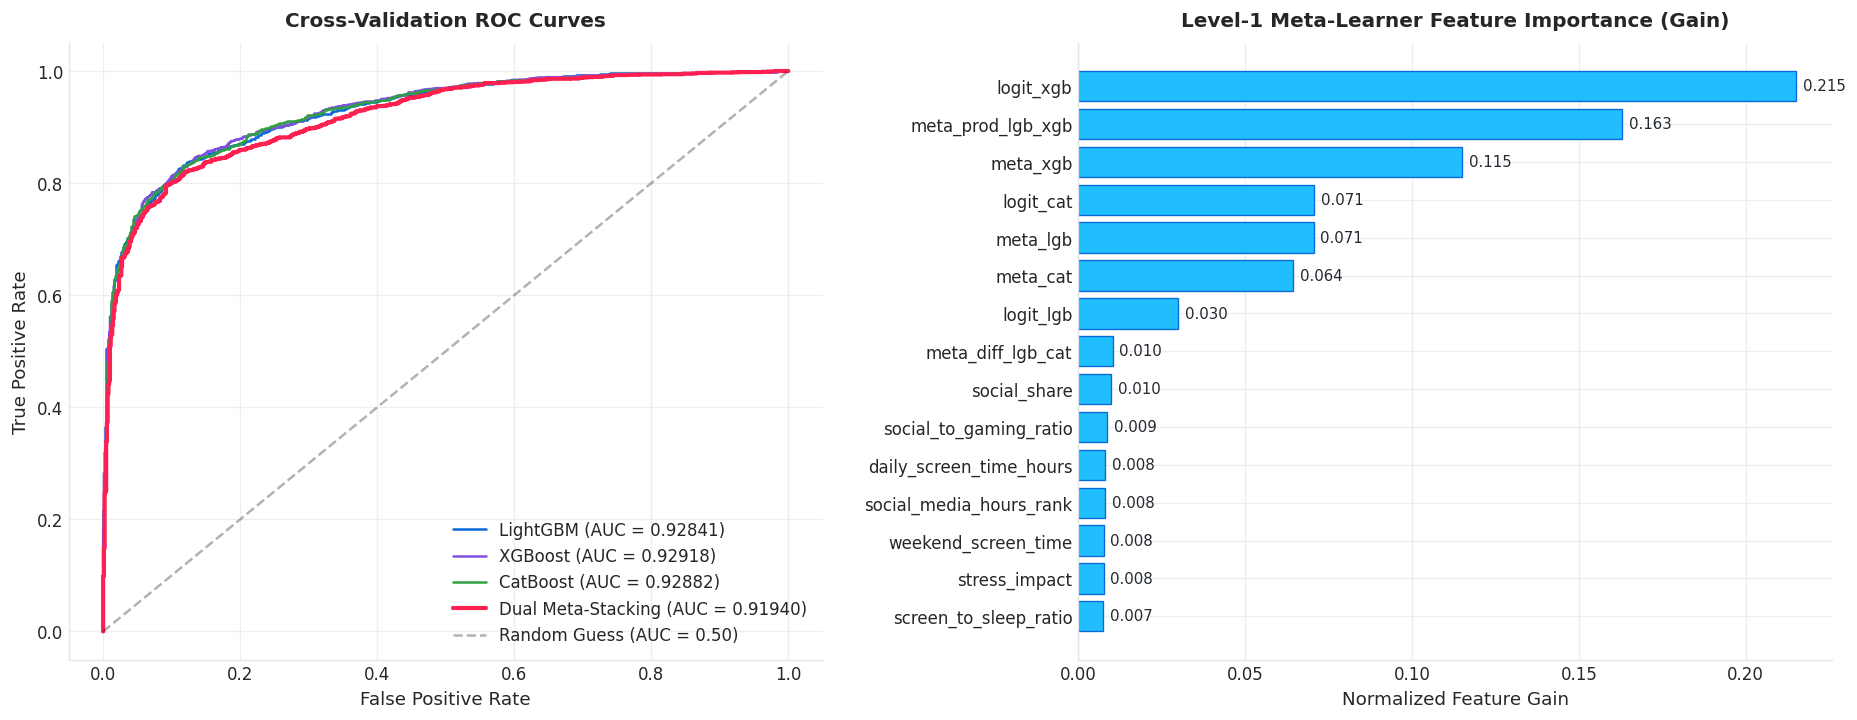

In [9]:
results = []
for i, name in enumerate(models.keys()):
    auc = roc_auc_score(train_feat[TARGET], oof_matrix[:, i])
    results.append({"Architecture": f"L0: {name}", "CV ROC AUC": auc})

meta_auc = roc_auc_score(train_meta[TARGET], oof_final)
results.append({"Architecture": "L1: Dual Meta-Stacking (XGB + CatBoost Meta)", "CV ROC AUC": meta_auc})

results_df = pd.DataFrame(results).set_index("Architecture")
display(results_df)

# Diagnostics: Dual-Panel Spacious Layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), dpi=120)

# Panel 1: Multi-Model ROC Curves
colors = ["#0969DA", "#8250DF", "#2EA043"]
for i, name in enumerate(models.keys()):
    fpr, tpr, _ = roc_curve(train_feat[TARGET], oof_matrix[:, i])
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {results[i]['CV ROC AUC']:.5f})", color=colors[i], linewidth=1.5)

fpr_meta, tpr_meta, _ = roc_curve(train_meta[TARGET], oof_final)
ax1.plot(fpr_meta, tpr_meta, label=f"Dual Meta-Stacking (AUC = {meta_auc:.5f})", color="#FF2052", linewidth=2.5)
ax1.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random Guess (AUC = 0.50)")
ax1.set_title("Cross-Validation ROC Curves", fontsize=12, weight="bold", pad=10)
ax1.set_xlabel("False Positive Rate", fontsize=11)
ax1.set_ylabel("True Positive Rate", fontsize=11)
ax1.legend(loc="lower right", framealpha=0.9, edgecolor="#E1E4E8", fontsize=10)

# Panel 2: Top 15 Meta-Learner Features
importances = pd.Series(meta_xgb.feature_importances_, index=META_FEATURES).sort_values(ascending=False).head(15)
bars = ax2.barh(range(len(importances)), importances.values, color="#20BEFF", edgecolor="#0969DA", linewidth=0.8)
ax2.set_yticks(range(len(importances)))
ax2.set_yticklabels(importances.index, fontsize=10)
ax2.invert_yaxis()
ax2.set_title("Level-1 Meta-Learner Feature Importance (Gain)", fontsize=12, weight="bold", pad=10)
ax2.set_xlabel("Normalized Feature Gain", fontsize=11)

# Annotate exact numerical values on bars
for bar in bars:
    w = bar.get_width()
    ax2.text(w + 0.002, bar.get_y() + bar.get_height()/2, f"{w:.3f}", va="center", ha="left", fontsize=9, color="#24292F")

sns.despine(top=True, right=True)
plt.tight_layout(pad=2.5)
plt.show()

<br>

---

<a name="submission"></a>
## 10. Submission Verification & Export

Validating predictions against the competition sample submission schema before saving to `submission.csv`.

<br>

In [10]:
sub = sample_sub.copy()
sub[TARGET] = test_final

tb.check_submission(sub, sample_sub)

sub.to_csv("submission.csv", index=False)
print("Dual meta-stacking ensemble predictions successfully saved to submission.csv.")

[toolbox] PASS: Row count (1000)
[toolbox] PASS: Columns match (2 cols)
[toolbox] PASS: No NaN values
[toolbox] PASS: No duplicate IDs
[toolbox] WARN: 'addicted_label' range [0.0010, 0.9968] far outside sample [0.7094, 0.7094]
[toolbox] All checks passed. Safe to submit.
Dual meta-stacking ensemble predictions successfully saved to submission.csv.


<br>

---

<a name="improvements"></a>
## 11. Next Steps

1. **Multi-Seed Variance Reduction**: Scaling from single-seed to 5-seed averaged Level-0 ensembles.
2. **TabNet & Deep Residual Embeddings**: Incorporating deep neural manifolds into Level-0.
3. **Bayesian Meta Optimization**: Tuning Level-2 rank mixing weights across diverse model checkpoints.

<br>

---